## Preprocessing

In [6]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix
from tqdm import tqdm

sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data_1.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data_1.h5ad")
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)
envi_latent_st = st_ad.obsm['envi_latent']
envi_latent_sc = sc_ad.obsm['envi_latent']

print(f"st_ad envi_latent shape: {envi_latent_st.shape}")
print(f"sc_ad envi_latent shape: {envi_latent_sc.shape}")
combined_envi_latent = np.concatenate([envi_latent_sc, envi_latent_st], axis=0)
print(combined_envi_latent.shape)
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)

cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)

n_components = 50
pca = PCA(n_components=n_components)
envi_pca = pca.fit_transform(combined_envi_latent)
print("Reduced shape:", envi_pca.shape)

# Flatten the (64, 64) matrices into 1D vectors
st_covet_sqrt_flat = st_ad.obsm["COVET_SQRT"].reshape(st_ad.shape[0], -1)
sc_covet_sqrt_flat = sc_ad.obsm["COVET_SQRT"].reshape(sc_ad.shape[0], -1)

covet_sqrt_combined = np.concatenate([st_covet_sqrt_flat, sc_covet_sqrt_flat], axis=0)
print("Shape after flattening: ", covet_sqrt_combined.shape)
covet_pca = pca.fit_transform(covet_sqrt_combined)
print("Reduced shape:", covet_pca.shape)

combined_matrix=np.concatenate([covet_pca, envi_pca], axis=1)
print(combined_matrix.shape)

Shape of combined_cell_types (283972,)
st_ad envi_latent shape: (276556, 512)
sc_ad envi_latent shape: (7416, 512)
(283972, 512)
Reduced shape: (283972, 50)
Shape after flattening:  (283972, 3844)
Reduced shape: (283972, 50)
(283972, 100)


In [7]:
sc_ad

AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', 'cell_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep_genes'
    uns: 'COVET_genes', 'hvg'
    obsm: 'COVET', 'COVET_SQRT', 'UMAP_exp', 'cell_type_niche', 'envi_latent'
    layers: 'log'

In [8]:
st_ad

AnnData object with n_obs × n_vars = 276556 × 254
    obs: 'fovID', 'fov_x', 'fov_y', 'volume', 'center_x', 'center_y', 'slice_id', 'sample_id', 'label', 'subclass', 'class_label', 'cell_id', 'cell_type', 'batch', 'cell_label', 'Layer_Depth', 'Depth'
    var: 'n_iso', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'COVET_genes'
    obsm: 'COVET', 'COVET_SQRT', 'cell_type_niche', 'envi_latent', 'imputation', 'spatial'

## Creating Adata

AnnData object with n_obs × n_vars = 283972 × 100
    obs: 'cell_type'
    obsm: 'combined_matrix'
         Falling back to preprocessing with `sc.pp.pca` and default params.


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


AttributeError: 'Legend' object has no attribute 'legendHandles'

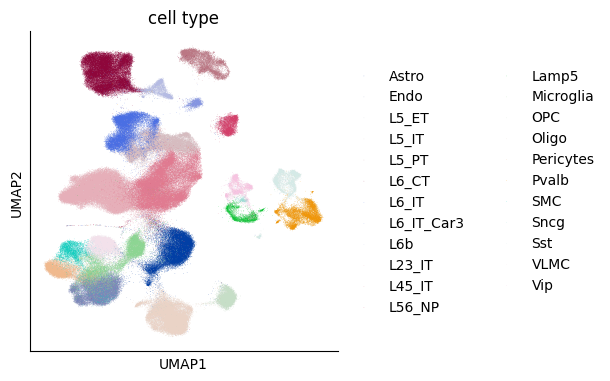

In [10]:
adata=ad.AnnData(X=combined_matrix)
adata.obs["cell_type"] = combined_cell_types
adata.obsm["combined_matrix"] = combined_matrix
print(adata)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.scatter(adata, basis='umap', color=['cell_type'], frameon=False)

# KNN Indices

In [ ]:
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

def compute_knn_indices(data, n_neighbors):
    """
    Computes k-nearest neighbors for each point in the dataset.

    :param data: (array) Data matrix of shape (n_samples, n_features)
    :param n_neighbors: (int) Number of nearest neighbors
    :return: (tuple) knn_indices (n_samples, k), knn_distances (n_samples, k), fitted NearestNeighbors object
    """
    n_samples = data.shape[0]
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(data)
    knn_indices = np.zeros((n_samples, n_neighbors), dtype=int)
    knn_distances = np.zeros((n_samples, n_neighbors), dtype=float)

    for i in tqdm(range(n_samples), desc="Computing kNN", ncols=80):
        distances, indices = nbrs.kneighbors(data[i].reshape(1, -1))
        knn_indices[i] = indices[0]
        knn_distances[i] = distances[0]
        
    return knn_indices, knn_distances, nbrs

In [ ]:
knn_indices_covet, knn_distances_covet, _ = compute_knn_indices(covet_pca, n_neighbors=10)
knn_indices_envi, knn_distances_envi, _= compute_knn_indices(envi_pca, n_neighbors=10)
print(knn_indices_envi.shape, knn_indices_covet.shape)
print(knn_distances_envi.shape, knn_distances_covet.shape)


Computing kNN: 100%|█████████████████████| 25932/25932 [00:28<00:00, 915.51it/s]

(25932, 10) (25932, 10)
(25932, 10) (25932, 10)


# SNN Using average
### calculates a similarity value using the found average distance between two cells

In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from tqdm import tqdm

def compute_snn_matrix(knn_indices, knn_distances, n_neighbors=10):
    """
    Computes the Shared Nearest Neighbor (SNN) matrix using average distances
    of shared neighbors instead of rankings.

    :param knn_indices: (array) Indices of k-nearest neighbors for each point (n_samples, k)
    :param knn_distances: (array) Distances to k-nearest neighbors (n_samples, k)
    :param n_neighbors: (int) Number of nearest neighbors considered (default 10)
    :return: (sparse matrix) Weighted SNN graph in CSR format
    """
    n_samples = knn_indices.shape[0]
    snn_matrix = np.zeros((n_samples, n_samples), dtype=np.float32)

    # Build neighbor distance dictionaries
    distance_dicts = [{knn_indices[i][j]: knn_distances[i][j] for j in range(knn_indices.shape[1])}
                      for i in range(n_samples)]

    for i in tqdm(range(n_samples), desc="Computing SNN Matrix", ncols=80):
        neighbors_i = set(knn_indices[i])

        for j in range(i + 1, n_samples):
            neighbors_j = set(knn_indices[j])
            shared_neighbors = neighbors_i.intersection(neighbors_j)

            if shared_neighbors:
                avg_distances = [
                    0.5 * (distance_dicts[i][v] + distance_dicts[j][v])
                    for v in shared_neighbors
                ]
                mean_avg_distance = np.mean(avg_distances)

                
                similarity = 1.0 / (1.0 + mean_avg_distance)  

                snn_matrix[i, j] = similarity
                snn_matrix[j, i] = similarity  

    return csr_matrix(snn_matrix)


In [12]:
snn_envi_using_avg=compute_snn_matrix(knn_indices_envi, knn_distances_envi)

Computing SNN Matrix: 100%|███████████████| 25932/25932 [05:52<00:00, 73.47it/s]


In [13]:
snn_covet_using_avg= compute_snn_matrix(knn_indices_covet, knn_distances_covet)

Computing SNN Matrix: 100%|███████████████| 25932/25932 [05:44<00:00, 75.25it/s]


In [14]:
snn_combined_avg= (snn_envi_using_avg + snn_covet_using_avg) / 2
print(snn_combined_avg)

  (0, 18)	0.09906657040119171
  (0, 60)	0.09663116931915283
  (0, 73)	0.21038475632667542
  (0, 142)	0.08760883659124374
  (0, 194)	0.20779947936534882
  (0, 206)	0.09436959773302078
  (0, 241)	0.22721414268016815
  (0, 400)	0.09670013934373856
  (0, 436)	0.09941519051790237
  (0, 511)	0.09484715014696121
  (0, 521)	0.11240070313215256
  (0, 557)	0.10198401659727097
  (0, 583)	0.09765375405550003
  (0, 585)	0.2190256267786026
  (0, 597)	0.10455987602472305
  (0, 631)	0.10071159154176712
  (0, 671)	0.10041891783475876
  (0, 753)	0.09849533438682556
  (0, 805)	0.09906871616840363
  (0, 854)	0.09092631191015244
  (0, 1084)	0.2113678753376007
  (0, 1097)	0.1182468831539154
  (0, 1139)	0.09952203929424286
  (0, 1149)	0.2223842740058899
  (0, 1182)	0.09559803456068039
  :	:
  (25931, 24312)	0.3687863051891327
  (25931, 24445)	0.056902412325143814
  (25931, 24542)	0.37322986125946045
  (25931, 24591)	0.3381235599517822
  (25931, 24753)	0.056792035698890686
  (25931, 24786)	0.05416321754455566

In [21]:
from scipy.sparse import save_npz

save_npz("/Users/anushka/Documents/Undergraduate-Project/Approaches/snn_after_average.npz", snn_combined_avg)


(25932, 25932)


In [22]:
from scipy.sparse import load_npz

snn_combined_avg_loaded = load_npz("/Users/anushka/Documents/Undergraduate-Project/Approaches/snn_after_average.npz")
print(snn_combined_avg_loaded.shape)

(25932, 25932)


In [23]:
adata.obsp["snn_graph"] = snn_combined_avg_loaded
print(adata)
raw_ad=sc.AnnData(adata.X)
raw_ad.obs_names, raw_ad.var_names=adata.obs_names, adata.var_names
adata.raw=raw_ad


AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    uns: 'pca', 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'combined_matrix', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'snn_graph'


# SNN that is simply the average distances
### uses mean averge distance directly as the similarity value

In [31]:
import numpy as np
from scipy.sparse import csr_matrix
from tqdm import tqdm

def compute_snn_avg_distance_matrix(knn_indices, knn_distances, n_neighbors=10):
    """
    Computes the Shared Nearest Neighbor (SNN) matrix using average distances
    of shared neighbors instead of rankings. Returns average distance (not similarity).
    
    :param knn_indices: (array) Indices of k-nearest neighbors for each point (n_samples, k)
    :param knn_distances: (array) Distances to k-nearest neighbors (n_samples, k)
    :param n_neighbors: (int) Number of nearest neighbors considered (default 10)
    :return: (sparse matrix) Weighted SNN graph with average distances in CSR format
    """
    n_samples = knn_indices.shape[0]
    snn_matrix = np.zeros((n_samples, n_samples), dtype=np.float32)

    # Build neighbor distance dictionaries
    distance_dicts = [
        {knn_indices[i][j]: knn_distances[i][j] for j in range(knn_indices.shape[1])}
        for i in range(n_samples)
    ]

    for i in tqdm(range(n_samples), desc="Computing SNN Avg-Distance Matrix", ncols=80):
        neighbors_i = set(knn_indices[i])
        for j in range(i + 1, n_samples):
            neighbors_j = set(knn_indices[j])
            shared_neighbors = neighbors_i.intersection(neighbors_j)

            if shared_neighbors:
                avg_distances = [
                    0.5 * (distance_dicts[i][v] + distance_dicts[j][v])
                    for v in shared_neighbors
                ]
                mean_avg_distance = np.mean(avg_distances)

                snn_matrix[i, j] = mean_avg_distance
                snn_matrix[j, i] = mean_avg_distance

    return csr_matrix(snn_matrix)


In [32]:
snn_envi_distances=compute_snn_avg_distance_matrix(knn_indices_envi, knn_distances_envi)
snn_covet_distances=compute_snn_avg_distance_matrix(knn_indices_covet, knn_distances_covet) 

Computing SNN Avg-Distance Matrix: 100%|██| 25932/25932 [05:50<00:00, 74.02it/s]


In [33]:
snn_combined_distances= (snn_envi_distances + snn_covet_distances) / 2
print(snn_combined_distances)
from scipy.sparse import save_npz
save_npz("/Users/anushka/Documents/Undergraduate-Project/Approaches/snn_after_distance.npz", snn_combined_distances)

  (0, 18)	2.0235555171966553
  (0, 60)	2.0871570110321045
  (0, 73)	0.6953130960464478
  (0, 142)	2.353593349456787
  (0, 194)	0.6937118768692017
  (0, 206)	2.149158239364624
  (0, 241)	0.6024731397628784
  (0, 400)	2.0853116512298584
  (0, 436)	2.0147061347961426
  (0, 511)	2.135819911956787
  (0, 521)	1.7241853475570679
  (0, 557)	1.951364517211914
  (0, 583)	2.060065507888794
  (0, 585)	0.6494162082672119
  (0, 597)	1.890974521636963
  (0, 631)	1.9823358058929443
  (0, 671)	1.9895706176757812
  (0, 753)	2.038191318511963
  (0, 805)	2.023500919342041
  (0, 854)	2.249479055404663
  (0, 1084)	0.6853705644607544
  (0, 1097)	1.6142206192016602
  (0, 1139)	2.0120065212249756
  (0, 1149)	0.542225182056427
  (0, 1182)	2.115116596221924
  :	:
  (25931, 24312)	0.17742377519607544
  (25931, 24445)	3.893486976623535
  (25931, 24542)	0.170087993144989
  (25931, 24591)	0.23688305914402008
  (25931, 24753)	3.9020256996154785
  (25931, 24786)	4.115678310394287
  (25931, 24837)	3.8212409019470215
  

In [44]:
from scipy.sparse import csr_matrix

snn_combined_distances_normalized = snn_combined_distances.copy()

snn_data = snn_combined_distances_normalized.data


min_val = snn_data.min()
max_val = snn_data.max()

if max_val > min_val:
    snn_combined_distances_normalized.data = (snn_data - min_val) / (max_val - min_val)
else:
    snn_combined_distances_normalized.data = np.zeros_like(snn_data)  # All values are the same

print(snn_combined_distances_normalized)

  (0, 18)	0.03397786771926308
  (0, 60)	0.03505998659467687
  (0, 73)	0.01137908727598293
  (0, 142)	0.039593147272497124
  (0, 194)	0.011351844055880972
  (0, 206)	0.03611487847584939
  (0, 241)	0.009799503794076622
  (0, 400)	0.035028589554237745
  (0, 436)	0.03382730390143633
  (0, 511)	0.03588793953174515
  (0, 521)	0.028884369253001183
  (0, 557)	0.03274960657306113
  (0, 583)	0.034599050457067335
  (0, 585)	0.010598195419619368
  (0, 597)	0.03172212828352783
  (0, 631)	0.03327655356843111
  (0, 671)	0.033399647004106206
  (0, 753)	0.034226881946838865
  (0, 805)	0.03397693878873846
  (0, 854)	0.03782174166548935
  (0, 1084)	0.011209924565337918
  (0, 1097)	0.027013424075345415
  (0, 1139)	0.0337813725462823
  (0, 1149)	0.008774442143670146
  (0, 1182)	0.035535692321981345
  :	:
  (25931, 24312)	0.0025676934600241683
  (25931, 24445)	0.06579297151558401
  (25931, 24542)	0.0024428821113483003
  (25931, 24591)	0.0035793365771673875
  (25931, 24753)	0.06593824975929033
  (25931, 2478

In [45]:
adata.obsp["snn_distances"] = snn_combined_distances
adata.obsp["snn_distances_normalized"] = snn_combined_distances_normalized
print(adata)
raw_ad=sc.AnnData(adata.X)
raw_ad.obs_names, raw_ad.var_names=adata.obs_names, adata.var_names
adata.raw=raw_ad

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    uns: 'pca', 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'combined_matrix', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'snn_distances', 'snn_distances_normalized'


# Original rbf matrix of seacells

In [ ]:
import multiprocessing
num_cores = multiprocessing.cpu_count()
from multiprocessing import cpu_count
import numpy as np
from joblib import Parallel, delayed
from scipy.sparse import lil_matrix
from tqdm.notebook import tqdm
def rbf_for_row(G, data, median_distances, i):
    """Helper function for computing radial basis function kernel for each row of the data matrix.

    :param G: (array) KNN graph representing nearest neighbour connections between cells
    :param data: (array) data matrix between which euclidean distances are computed for RBF
    :param median_distances: (array) radius for RBF - the median distance between cell and k nearest-neighbours
    :param i: (int) data row index for which RBF is calculated
    :return: sparse matrix containing computed RBF for row
    """
    # convert row to binary numpy array
    row_as_array = G[i, :].toarray().ravel()

    # compute distances ||x - y||^2 in PC/original X sp ace
    numerator = np.sum(np.square(data[i, :] - data), axis=1, keepdims=False)

    # compute radii - median distance is distance to kth nearest neighbor
    denominator = median_distances[i] * median_distances

    # exp
    full_row = np.exp(-numerator / denominator)

    # masked row - to contain only indices captured by G matrix
    masked_row = np.multiply(full_row, row_as_array)

    return lil_matrix(masked_row)

def kth_neighbor_distance(distances, k, i):
    """Returns distance to kth nearest neighbor.

    Distances: sparse CSR matrix
    k: kth nearest neighbor
    i: index of row
    .
    """
    # convert row to 1D array
    row_as_array = distances[i, :].toarray().ravel()

    # number of nonzero elements
    num_nonzero = np.sum(row_as_array > 0)

    # argsort
    kth_neighbor_idx = np.argsort(np.argsort(-row_as_array)) == num_nonzero - k
    return np.linalg.norm(row_as_array[kth_neighbor_idx])


def rbf(adata, k: int = 15, graph_construction="union"):
        """Initialize adaptive bandwith RBF kernel (as described in C-isomap).

        :param k: (int) number of nearest neighbors for RBF kernel
        :return: (sparse matrix) constructed RBF kernel
        """
        import scanpy as sc

        knn_graph_distances = adata.obsp["distances"]
        n, d=adata.obsm["X_pca"].shape
        # Binarize distances to get connectivity
        knn_graph = knn_graph_distances.copy()
        knn_graph[knn_graph != 0] = 1
        # Include self as neighbour
        knn_graph.setdiag(1)

        knn_graph = knn_graph
        
            # compute median distance for each point amongst k-nearest neighbors
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
            median = k // 2
            median_distances = parallel(
                delayed(kth_neighbor_distance)(knn_graph_distances, median, i)
                for i in tqdm(range(n))
            )

        # convert to numpy array
        median_distances = np.array(median_distances)

       
        print(
            f"Parameter graph_construction = {graph_construction} being used to build KNN graph..."
        )
        if graph_construction == "union":
            sym_graph = (knn_graph + knn_graph.T > 0).astype(float)
        elif graph_construction in ["intersect", "intersection"]:
            knn_graph = (knn_graph > 0).astype(float)
            sym_graph = knn_graph.multiply(knn_graph.T)
        else:
            raise ValueError(
                f"Parameter graph_construction = {graph_construction} is not valid. \
             Please select `union` or `intersection`"
            )
        
        sym_graph= sym_graph
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
            similarity_matrix_rows = parallel(
                delayed(rbf_for_row)(
                    sym_graph, adata.obsm["X_pca"], median_distances, i
                )
                for i in tqdm(range(n))
            )

      
        similarity_matrix = lil_matrix((n, n))
        for i in tqdm(range(n)):
            similarity_matrix[i] = similarity_matrix_rows[i]

        
        M = (similarity_matrix).tocsr()
        return M


In [38]:
similarity_matrix_rbf=rbf(adata)

  0%|          | 0/25932 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/25932 [00:00<?, ?it/s]

  0%|          | 0/25932 [00:00<?, ?it/s]

# Similarity matrix using snn distances

In [ ]:
import multiprocessing
num_cores = multiprocessing.cpu_count()
from multiprocessing import cpu_count
import numpy as np
from joblib import Parallel, delayed
from scipy.sparse import lil_matrix
from tqdm.notebook import tqdm
def rbf_for_row(G, data, median_distances, i):
    """Helper function for computing radial basis function kernel for each row of the data matrix.

    :param G: (array) KNN graph representing nearest neighbour connections between cells
    :param data: (array) data matrix between which euclidean distances are computed for RBF
    :param median_distances: (array) radius for RBF - the median distance between cell and k nearest-neighbours
    :param i: (int) data row index for which RBF is calculated
    :return: sparse matrix containing computed RBF for row
    """
    # convert row to binary numpy array
    row_as_array = G[i, :].toarray().ravel()

    # compute distances ||x - y||^2 in PC/original X space
    numerator = np.sum(np.square(data[i, :] - data), axis=1, keepdims=False)

    # compute radii - median distance is distance to kth nearest neighbor
    denominator = median_distances[i] * median_distances

    # exp
    full_row = np.exp(-numerator / denominator)

    # masked row - to contain only indices captured by G matrix
    masked_row = np.multiply(full_row, row_as_array)

    return lil_matrix(masked_row)

def kth_neighbor_distance(distances, k, i):
    """Returns distance to kth nearest neighbor.

    Distances: sparse CSR matrix
    k: kth nearest neighbor
    i: index of row
    .
    """
    # convert row to 1D array
    row_as_array = distances[i, :].toarray().ravel()

    # number of nonzero elements
    num_nonzero = np.sum(row_as_array > 0)

    # argsort
    kth_neighbor_idx = np.argsort(np.argsort(-row_as_array)) == num_nonzero - k
    return np.linalg.norm(row_as_array[kth_neighbor_idx])


def similarity_snn_distances(adata, k: int = 15, graph_construction="union"):
        """Initialize adaptive bandwith RBF kernel (as described in C-isomap).

        :param k: (int) number of nearest neighbors for RBF kernel
        :return: (sparse matrix) constructed RBF kernel
        """
        import scanpy as sc
        print("Computing SNN distances...")
        knn_graph_distances = adata.obsp["snn_distances_normalized"]  # directly using the normalized snn distances
        #hwo does thsi make any sense 
        n, d=adata.obsm["X_pca"].shape
        # Binarize distances to get connectivity
        knn_graph = knn_graph_distances.copy()
        knn_graph[knn_graph != 0] = 1
        # Include self as neighbour
        knn_graph.setdiag(1)

        knn_graph = knn_graph
        
            # compute median distance for each point amongst k-nearest neighbors
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
            median = k // 2
            median_distances = parallel(
                delayed(kth_neighbor_distance)(knn_graph_distances, median, i)
                for i in tqdm(range(n))
            )

        # convert to numpy array
        median_distances = np.array(median_distances)

       
        print(
            f"Parameter graph_construction = {graph_construction} being used to build KNN graph..."
        )
        if graph_construction == "union":
            sym_graph = (knn_graph + knn_graph.T > 0).astype(float)
        elif graph_construction in ["intersect", "intersection"]:
            knn_graph = (knn_graph > 0).astype(float)
            sym_graph = knn_graph.multiply(knn_graph.T)
        else:
            raise ValueError(
                f"Parameter graph_construction = {graph_construction} is not valid. \
             Please select `union` or `intersection`"
            )
        
        sym_graph= sym_graph
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
            similarity_matrix_rows = parallel(
                delayed(rbf_for_row)(
                    sym_graph, adata.obsm["X_pca"], median_distances, i
                )
                for i in tqdm(range(n))
            )

      
        similarity_matrix = lil_matrix((n, n))
        for i in tqdm(range(n)):
            similarity_matrix[i] = similarity_matrix_rows[i]

        
        M = (similarity_matrix).tocsr()
        return M


In [51]:
similarity_matrix_snn_distances=similarity_snn_distances(adata)

Computing SNN distances...


  0%|          | 0/25932 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/25932 [00:00<?, ?it/s]

  0%|          | 0/25932 [00:00<?, ?it/s]

# SNN Based rbf
### Directly using the average distance similarity score based SNN Matrix as an input 

In [39]:
# optimization
# for parallelizing stuff
def snn_rbf_row(i, snn_dense_row):
    return np.exp(-1 / (snn_dense_row + 1e-8))

from multiprocessing import cpu_count
import numpy as np
from joblib import Parallel, delayed
from scipy.sparse import lil_matrix
from tqdm.notebook import tqdm
NUM_CORES = cpu_count()

def snn_rbf_kernel(adata,  graph_construction="union"):
        """
        Compute the Shared Nearest Neighbor (SNN) based RBF kernel.
        Instead of Euclidean distance, we use SNN similarity scores.
        
        :return: (sparse matrix) SNN-RBF kernel matrix
        """

        snn_matrix= adata.obsp["snn_graph"]
        
        
        # Ensure symmetry in SNN matrix (if not already)
        sym_snn_matrix = (snn_matrix + snn_matrix.T) / 2
        n, d=adata.obsm["X_pca"].shape
        # Convert to dense format (if needed for iteration)
        snn_dense = sym_snn_matrix.toarray()
        num_cores = cpu_count()
        # Compute kernel using SNN weights instead of Euclidean distances
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
                    similarity_matrix_rows = parallel(
                        delayed(snn_rbf_row)(i, snn_dense[i]) for i in tqdm(range(n))
                        )
        
        
        similarity_matrix = lil_matrix((n,n))
        for i in tqdm(range(n)):
            similarity_matrix[i] = similarity_matrix_rows[i]
        
        # Ensure diagonal elements are exactly 1
        similarity_matrix.setdiag(1.0)
        
        
        M = similarity_matrix.tocsr()
        return M


In [ ]:
similarity_matrix_snn_rbf= snn_rbf_kernel(adata, snn_combined_)

  0%|          | 0/25932 [00:00<?, ?it/s]

  0%|          | 0/25932 [00:00<?, ?it/s]

In [ ]:
similarity_matrix_snn_rbf_inv= snn_rbf_kernel(adata, snn_combined_avg)

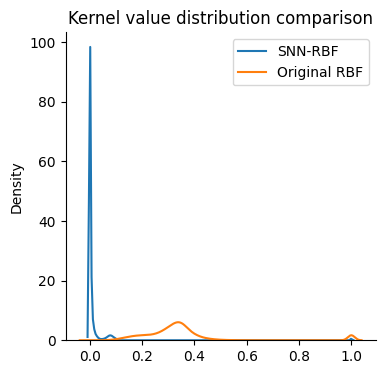

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(similarity_matrix_snn_rbf.data, label="SNN-RBF")
sns.kdeplot(similarity_matrix_rbf.data, label="Original RBF")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

# SNN directly as a sim matrix

In [20]:
def snn_kernel(snn, graph_construction="union"):
        """
        Compute the Shared Nearest Neighbor (SNN) similarity kernel.
        Instead of converting SNN to distances and using RBF, we use the raw SNN similarity,
        normalized between 0 and 1 to act as a kernel.
        
        :return: (sparse matrix) normalized SNN similarity matrix
        """
        print("Welcome to normalized SNN kernel!")
        normalized_snn= snn

        print("Symmetrizing the SNN graph...")


        # Force diagonal to 1 (each cell is fully similar to itself)
        normalized_snn.setdiag(1.0)

        print("Converting to CSR format...")

        M = normalized_snn.tocsr()
        return M


In [21]:
similarity_matrix_using_snn= snn_kernel(snn_combined_avg)

Welcome to normalized SNN kernel!
Symmetrizing the SNN graph...
Converting to CSR format...


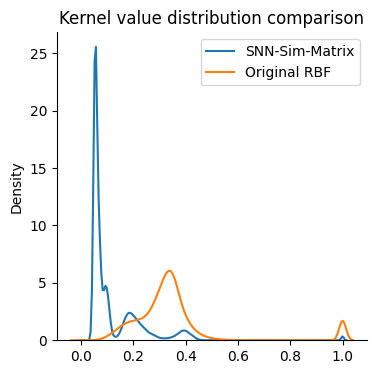

In [23]:
sns.kdeplot(similarity_matrix_using_snn.data, label="SNN-Sim-Matrix")
sns.kdeplot(similarity_matrix_rbf.data, label="Original RBF")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

# SIM matrix after normalizing the snn values

In [25]:
from scipy.sparse import csr_matrix

snn_combined_avg_normalized = snn_combined_avg.copy()
snn_data = snn_combined_avg_normalized.data
min_val = snn_data.min()
max_val = snn_data.max()

# Normalize the data
if max_val > min_val:
    snn_combined_avg_normalized.data = (snn_data - min_val) / (max_val - min_val)
else:
    snn_combined_avg_normalized.data = np.zeros_like(snn_data)  # all values are the same
print(snn_combined_avg_normalized)

  (0, 0)	1.0
  (0, 18)	0.09525268659846199
  (0, 60)	0.09280697583489195
  (0, 73)	0.20505924437499662
  (0, 142)	0.08374644924323742
  (0, 194)	0.2053940992105382
  (0, 206)	0.09053583043236271
  (0, 241)	0.22165523183415217
  (0, 400)	0.09287623782739783
  (0, 436)	0.09560278251413043
  (0, 511)	0.09101540444896172
  (0, 521)	0.10864326615576461
  (0, 557)	0.09818248309749039
  (0, 583)	0.09383388943643023
  (0, 585)	0.2149603797595693
  (0, 597)	0.1007692468029121
  (0, 631)	0.09690467153822285
  (0, 671)	0.09661075886785274
  (0, 753)	0.09467903239457023
  (0, 805)	0.09525484144926048
  (0, 854)	0.08707796829164828
  (0, 1084)	0.2087455356645935
  (0, 1097)	0.11451419456687602
  (0, 1139)	0.09571008360892647
  (0, 1149)	0.23711270985961808
  :	:
  (25931, 24542)	0.37024775720189823
  (25931, 24591)	0.3366797608192492
  (25931, 24753)	0.05279919287669064
  (25931, 24786)	0.05015924625642267
  (25931, 24837)	0.05386540257681819
  (25931, 24897)	0.3680947918978491
  (25931, 24965)	0.0

# Calculating similarity matrix using this normalized matrix

In [26]:
similarity_matrix_using_snn= snn_kernel(snn_combined_avg_normalized)

Welcome to normalized SNN kernel!
Symmetrizing the SNN graph...
Converting to CSR format...


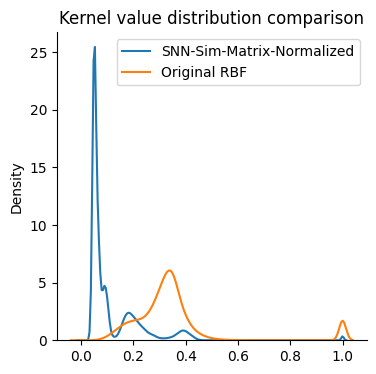

In [27]:
sns.kdeplot(similarity_matrix_using_snn.data, label="SNN-Sim-Matrix-Normalized")
sns.kdeplot(similarity_matrix_rbf.data, label="Original RBF")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

# SEACells application

In [17]:
import SEACells
n_SEACells=100 
build_kernel_on='X_pca'
n_waypoint_eigs=10
model= SEACells.core.SEACells(adata, 
                              build_kernel_on= build_kernel_on,
                              n_SEACells=n_SEACells,
                              convergence_epsilon=1e-5
                              )

Welcome to SEACells!


In [18]:
model.construct_kernel_matrix_updated()

using your code
Using the updated snn_kernel to calculate this 
Welcome to normalized SNN kernel!
Converting to CSR format...


In [19]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 98 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 12/12 [00:06<00:00,  1.72it/s]

Selecting 2 cells from greedy initialization.


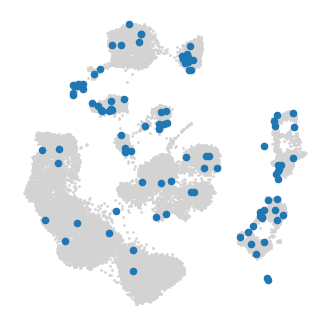

In [20]:
SEACells.plot.plot_initialization(adata, model)

In [ ]:
model.fit(min_iter=10, max_iter=50)
print (f'Ran for {len(model.RSS_iters)} iterations')

Randomly initialized A matrix.
Setting convergence threshold at 0.00389
Starting iteration 1.


In [1]:
SEACells.plot.plot_2D(adata, colour_metacells=False)

NameError: name 'SEACells' is not defined